# COVID-19 in India: Data Visualization

This notebook provides visual insights into the COVID-19 pandemic in India using the dataset curated by **Sudalai Rajkumar**.

### Dataset Credits
**Author:** Sudalai Rajkumar  
**Source:** [Kaggle - COVID-19 in India](https://www.kaggle.com/datasets/sudalairajkumar/covid19-in-india)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

## 1. Load the Datasets

In [2]:
covid_df = pd.read_csv('covid_19_india.csv')
vaccine_df = pd.read_csv('covid_vaccine_statewise.csv')
testing_df = pd.read_csv('StatewiseTestingDetails.csv')

# Convert Date columns to datetime
covid_df['Date'] = pd.to_datetime(covid_df['Date'])
vaccine_df['Updated On'] = pd.to_datetime(vaccine_df['Updated On'])
testing_df['Date'] = pd.to_datetime(testing_df['Date'])

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 2. State-wise Analysis
Comparing the total cases across different states.

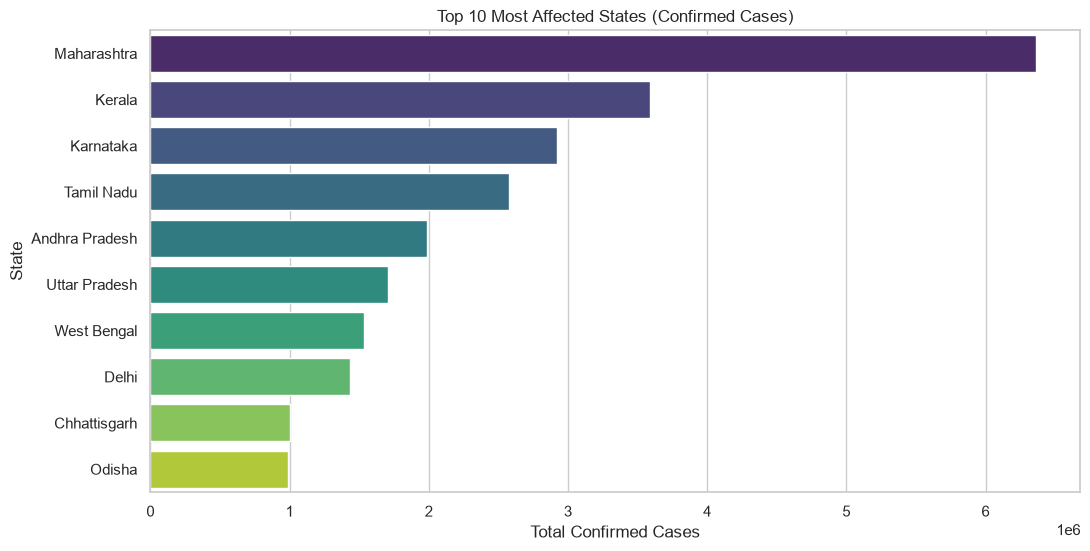

In [15]:
# ============================================================
# Top 10 Most Affected States by Confirmed COVID-19 Cases
# ============================================================

# Select data for the most recent (latest) available date
latest_state_data = covid_df[covid_df['Date'] == covid_df['Date'].max()]

# Sort states in descending order based on Confirmed cases
# and select the top 10 most affected states
top_10_states = (
    latest_state_data
    .sort_values(by='Confirmed', ascending=False)
    .head(10)
)

# ------------------------------------------------------------
# Create a bar chart
# ------------------------------------------------------------

# Set the figure size (width = 12 inches, height = 6 inches)
plt.figure(figsize=(12, 6))

# Create a horizontal bar plot
sns.barplot(
    data=top_10_states,                 # Dataset containing top 10 states
    x='Confirmed',                      # X-axis: Total Confirmed Cases
    y='State/UnionTerritory',           # Y-axis: State/Union Territory names
    palette='viridis'                   # Color palette for the bars
)

# ------------------------------------------------------------
# Add chart title and axis labels
# ------------------------------------------------------------

# Set the title of the graph
plt.title('Top 10 Most Affected States (Confirmed Cases)')

# Label the X-axis
plt.xlabel('Total Confirmed Cases')

# Label the Y-axis
plt.ylabel('State')

# Display the completed graph
plt.show()

## 3. Vaccination Progress
Tracking the vaccination drive across India.

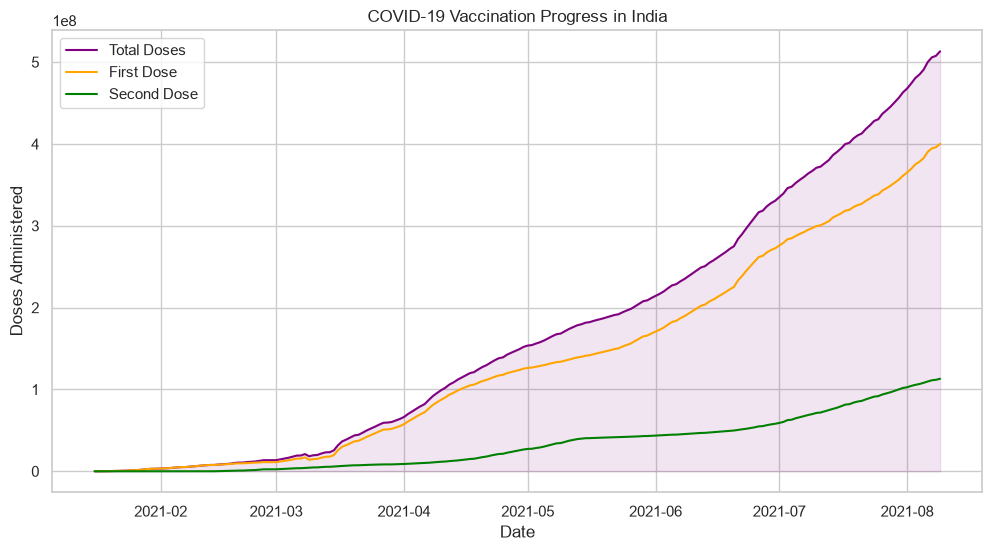

In [16]:
# ============================================================
# COVID-19 Vaccination Progress in India
# ============================================================

# Filter the vaccination dataset to include only India's data
india_vaccination = vaccine_df[vaccine_df['State'] == 'India']

# ------------------------------------------------------------
# Create a figure for the line chart
# ------------------------------------------------------------

# Set the figure size (width = 12 inches, height = 6 inches)
plt.figure(figsize=(12, 6))

# ------------------------------------------------------------
# Plot Total Doses Administered
# ------------------------------------------------------------

# Draw a line showing the total vaccine doses administered over time
plt.plot(
    india_vaccination['Updated On'],               # X-axis: Date
    india_vaccination['Total Doses Administered'], # Y-axis: Total doses
    label='Total Doses',
    color='purple'
)

# ------------------------------------------------------------
# Plot First Dose Administered
# ------------------------------------------------------------

# Draw a line showing the first doses administered over time
plt.plot(
    india_vaccination['Updated On'],               # X-axis: Date
    india_vaccination['First Dose Administered'],  # Y-axis: First dose
    label='First Dose',
    color='orange'
)

# ------------------------------------------------------------
# Plot Second Dose Administered
# ------------------------------------------------------------

# Draw a line showing the second doses administered over time
plt.plot(
    india_vaccination['Updated On'],                # X-axis: Date
    india_vaccination['Second Dose Administered'],  # Y-axis: Second dose
    label='Second Dose',
    color='green'
)

# ------------------------------------------------------------
# Highlight the area under the Total Doses line
# ------------------------------------------------------------

# Fill the area below the Total Doses curve for better visualization
plt.fill_between(
    india_vaccination['Updated On'],
    india_vaccination['Total Doses Administered'],
    alpha=0.1,             # Transparency level
    color='purple'
)

# ------------------------------------------------------------
# Add chart title, axis labels, and legend
# ------------------------------------------------------------

# Set the chart title
plt.title('COVID-19 Vaccination Progress in India')

# Label the X-axis
plt.xlabel('Date')

# Label the Y-axis
plt.ylabel('Doses Administered')

# Display the legend to identify each line
plt.legend()

# Display the completed graph
plt.show()